# EDA of the PassivUK temperature time series dataset

In [82]:
import os
from datetime import datetime
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.dates import DayLocator, DateFormatter, HourLocator

## Load data

In [53]:
data_path = "data/PST_Data_20260216"
temperature_files = [f for f in glob(os.path.join(data_path, "*.csv")) if "Events" not in f]
events_files = [f for f in glob(os.path.join(data_path, "*_Events_*_*.csv"))]

In [54]:
# First house:
house_id = temperature_files[0].split("/")[-1].split("_")[0]
house_df = pd.read_csv(temperature_files[0])

In [55]:
house_id

'30436'

# Preprocessing

In [56]:
# Convert time to datetime
house_df["Datetime"] = [datetime.strptime(t, '%Y-%m-%d %H:%M') for t in house_df['Time (UTC)'].values]

In [57]:
house_df.head()

,Time (UTC),Room temperature (Zone 1) (°C),Setpoint temperature (Zone 1) (°C),Space heating (0/1),Zone 1 heating (0/1),Flow temperature setpoint (°C),Hot water temperature (°C),Hot water usage setting,Hot water (0/1),Immersion call (0/1),Immersion status (0/1),Hot water setpoint (°C),Flow temperature (°C),Return temperature (°C),Defrost status (0/1),Tariff rate (p/kWh),External temperature (°C),Datetime
0,2025-10-01 00:00,21.7,22.0,1.0,1.0,48.0,50.0,NaN,0.0,1.0,0.0,20.0,27.0,25.0,0.0,NaN,19.0,2025-10-01 00:00:00
1,2025-10-01 00:05,21.7,22.0,0.0,0.0,48.0,50.0,NaN,0.0,1.0,0.0,20.0,25.0,25.0,0.0,NaN,19.0,2025-10-01 00:05:00
2,2025-10-01 00:10,21.7,22.0,0.0,0.0,48.0,50.0,NaN,0.0,1.0,0.0,20.0,25.0,25.0,0.0,NaN,19.0,2025-10-01 00:10:00
3,2025-10-01 00:15,21.7,22.0,1.0,1.0,55.0,50.0,NaN,0.0,1.0,0.0,20.0,25.0,24.0,0.0,NaN,19.0,2025-10-01 00:15:00
4,2025-10-01 00:20,21.7,22.0,1.0,1.0,55.0,50.0,NaN,0.0,1.0,0.0,20.0,25.0,24.0,0.0,NaN,19.0,2025-10-01 00:20:00


In [58]:
house_temp_df =  house_df.reindex(columns = ["Room temperature (Zone 1) (°C)",
                                             "Setpoint temperature (Zone 1) (°C)",
                                             "Flow temperature setpoint (°C)",
                                             "Flow temperature (°C)",
                                             "Return temperature (°C)",
                                             "External temperature (°C)"])            
house_temp_df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Room temperature (Zone 1) (°C),39745.0,21.939577,2.293242,0.0,21.8,22.1,22.5,24.2
Setpoint temperature (Zone 1) (°C),39745.0,19.790200,4.895560,8.0,21.5,22.0,22.0,27.5
Flow temperature setpoint (°C),39745.0,39.015222,6.280228,35.0,35.0,35.0,41.0,55.0
Flow temperature (°C),39745.0,27.096339,9.489861,8.0,20.0,26.0,34.0,63.0
Return temperature (°C),39745.0,24.449541,8.838586,7.0,17.0,24.0,30.0,58.0
External temperature (°C),39745.0,7.555542,4.229876,-4.0,5.0,8.0,11.0,19.0


# Plot house time series

In [68]:
colours = ["#dc267f", "#ffb000", "#1589e8", "#631ff3", "#fe5100"] # - IBM colourblind palette

In [69]:
num_days = int(len(house_df)/(12*24))
num_weeks = int(num_days/7)

In [70]:
datapoints_in_week = (12*24)*7
datapoints_in_day = (12*24)

### Plot by week

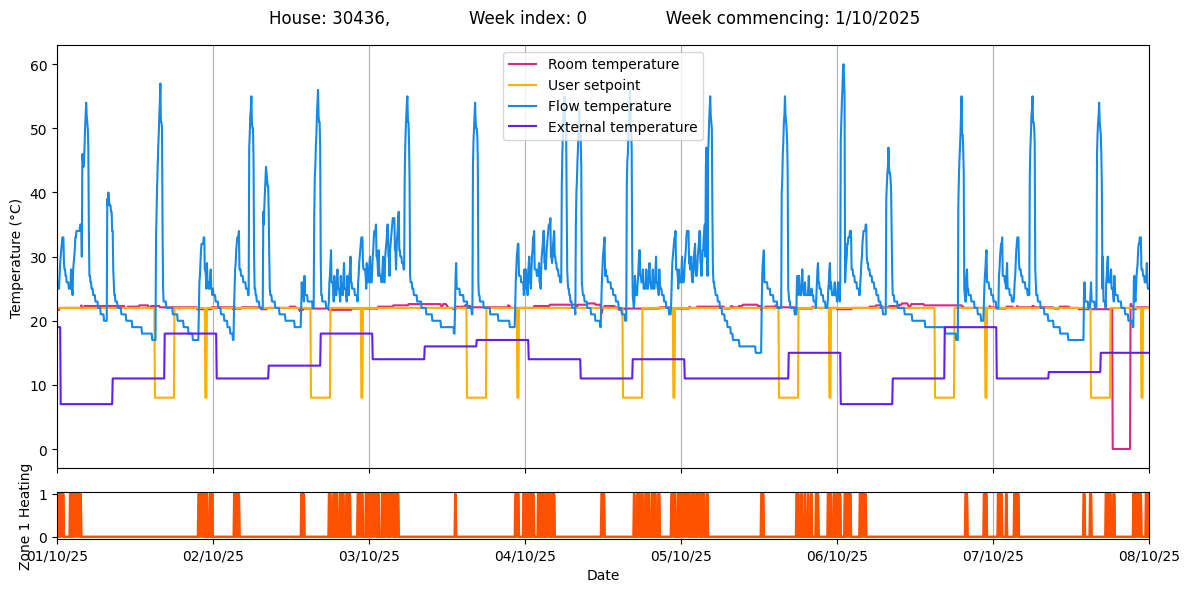

In [ ]:
for i in range(num_weeks):
    # Slice by week
    start_index = i*datapoints_in_week
    end_index = i*datapoints_in_week + datapoints_in_week

    dates = house_df["Datetime"][start_index:end_index]
    room_temp = house_df["Room temperature (Zone 1) (°C)"][start_index:end_index]
    user_setpoint = house_df["Setpoint temperature (Zone 1) (°C)"][start_index:end_index]
    flow_temp = house_df["Flow temperature (°C)"][start_index:end_index]
    # flow_setpoint = house_df["Flow temperature setpoint (°C)"][start_index:end_index]
    ext_temp = house_df["External temperature (°C)"][start_index:end_index]
    heating_on = house_df["Zone 1 heating (0/1)"][start_index:end_index]

    # Make subfigs
    fig, (temp_plot, heating_plot) = plt.subplots(2, 1, sharex=True, height_ratios=[9, 1], figsize=(12,6), layout="tight")
    fig.suptitle(f"House: {house_id}, \
              Week index: {i} \
              Week commencing: {dates[start_index].day}/{dates[start_index].month}/{dates[start_index].year}")
    plt.xlabel("Date")
    plt.xlim(house_df["Datetime"][start_index],house_df["Datetime"][end_index])

    # Plot temperature variation across training dataset
    temp_plot.plot(dates, room_temp, label="Room temperature", c=colours[0])
    temp_plot.plot(dates, user_setpoint, label="User setpoint", c=colours[1])
    temp_plot.plot(dates, flow_temp, label="Flow temperature", c=colours[2])
    # plt.plot(dates, flow_setpoint, label="Flow setpoint")
    temp_plot.plot(dates, ext_temp, label="External temperature", c=colours[3])
    ax = fig.gca()
    ax.xaxis.set_major_locator(DayLocator(interval=1))
    ax.xaxis.set_major_formatter(DateFormatter('%d/%m/%y'))
    temp_plot.grid(visible=True, axis="x")
    temp_plot.set_ylabel("Temperature (°C)")
    temp_plot.legend()

    heating_plot.plot(dates, heating_on, c=colours[4])
    heating_plot.fill_between(dates, heating_on, np.zeros(len(dates)), color=colours[4])
    heating_plot.grid(visible=True, axis="x")
    heating_plot.set_ylabel("Zone 1 Heating")
    plt.show()

### Plot by day

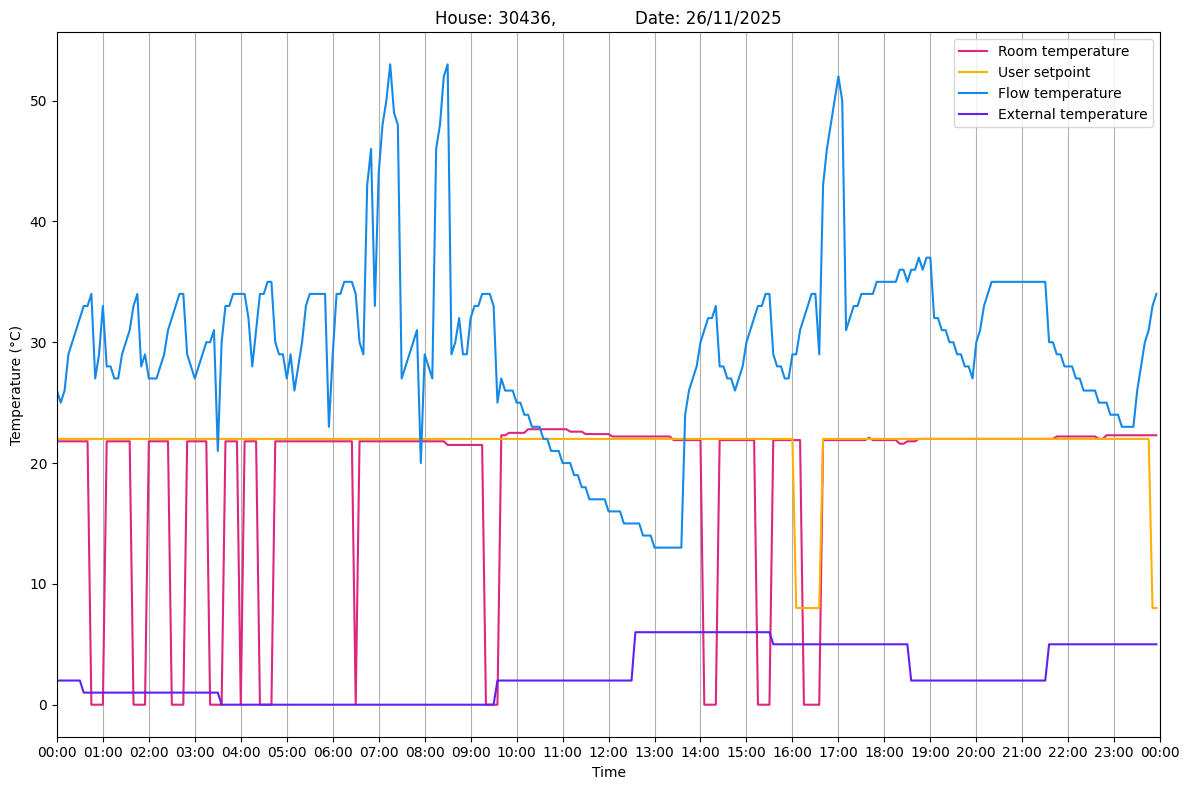

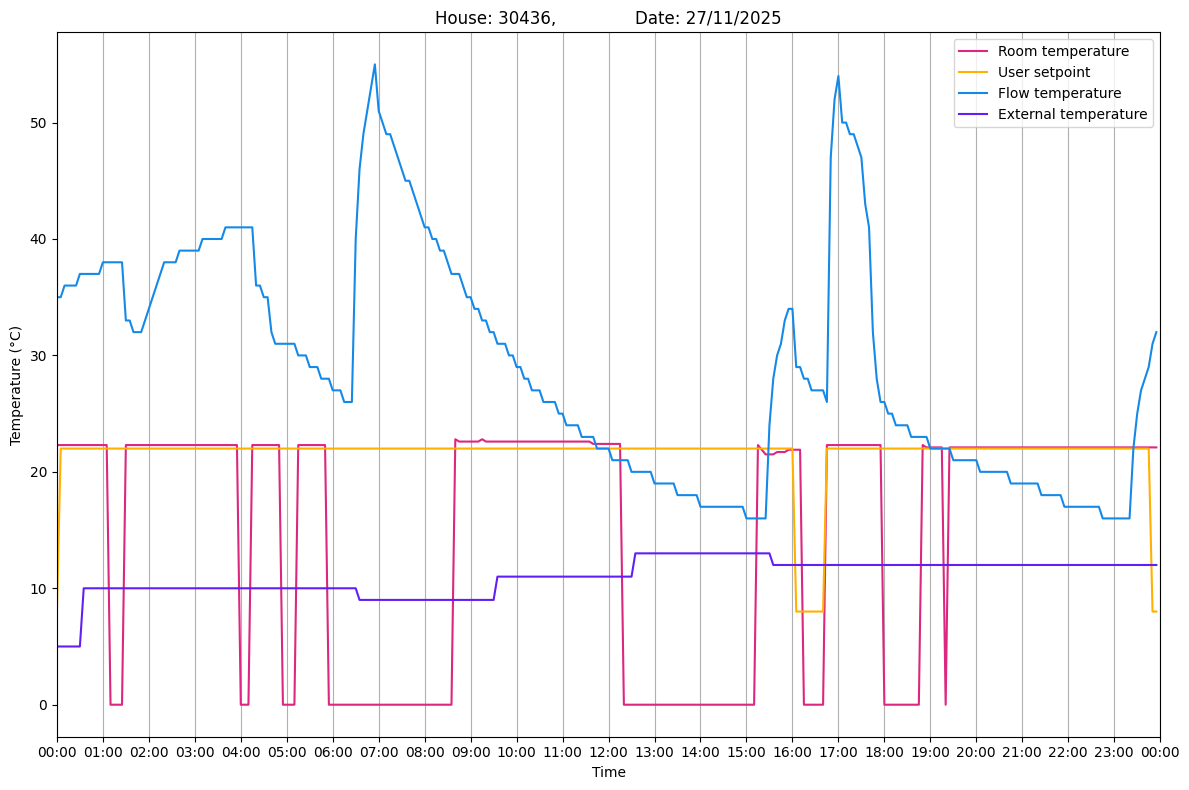

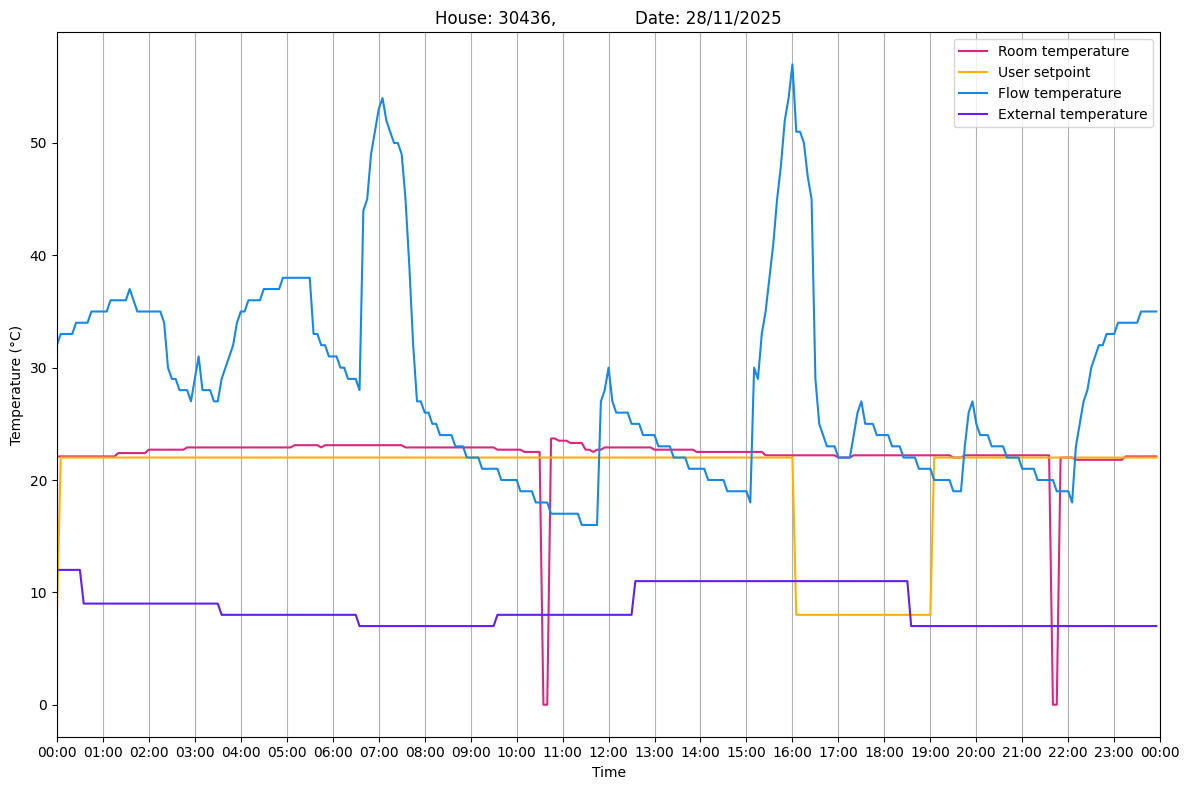

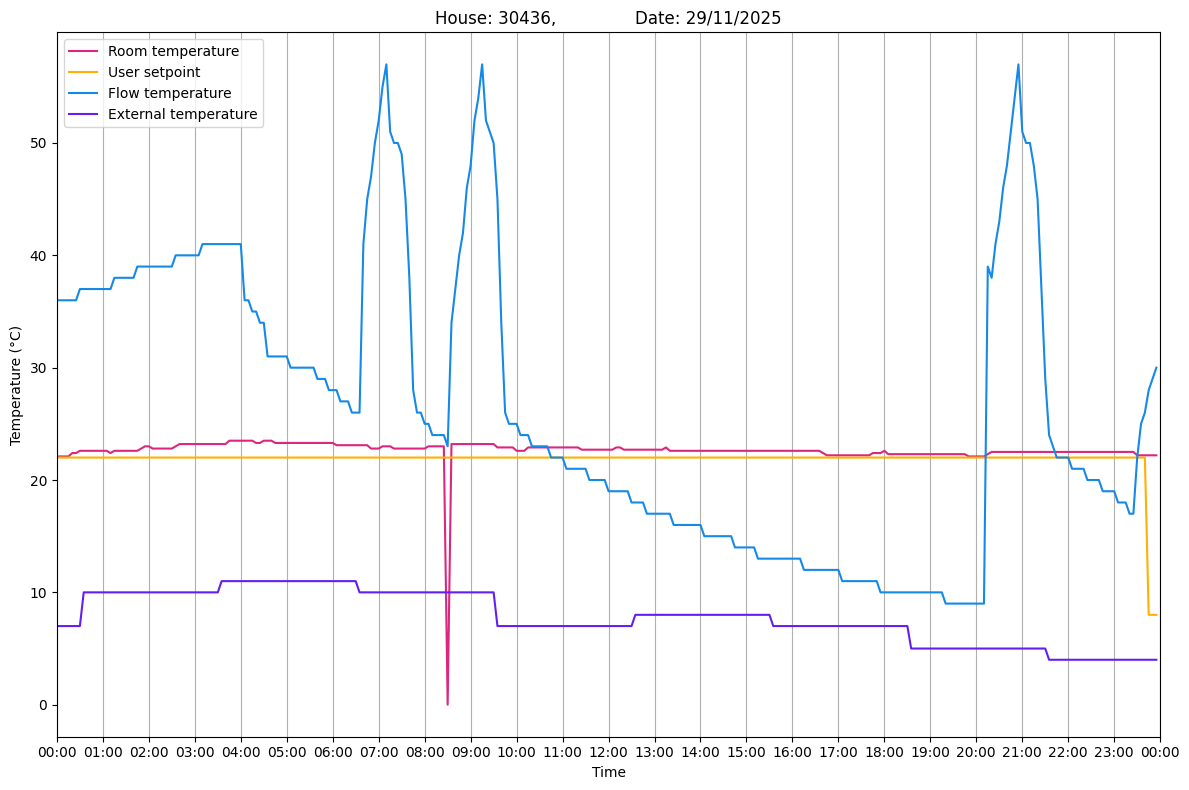

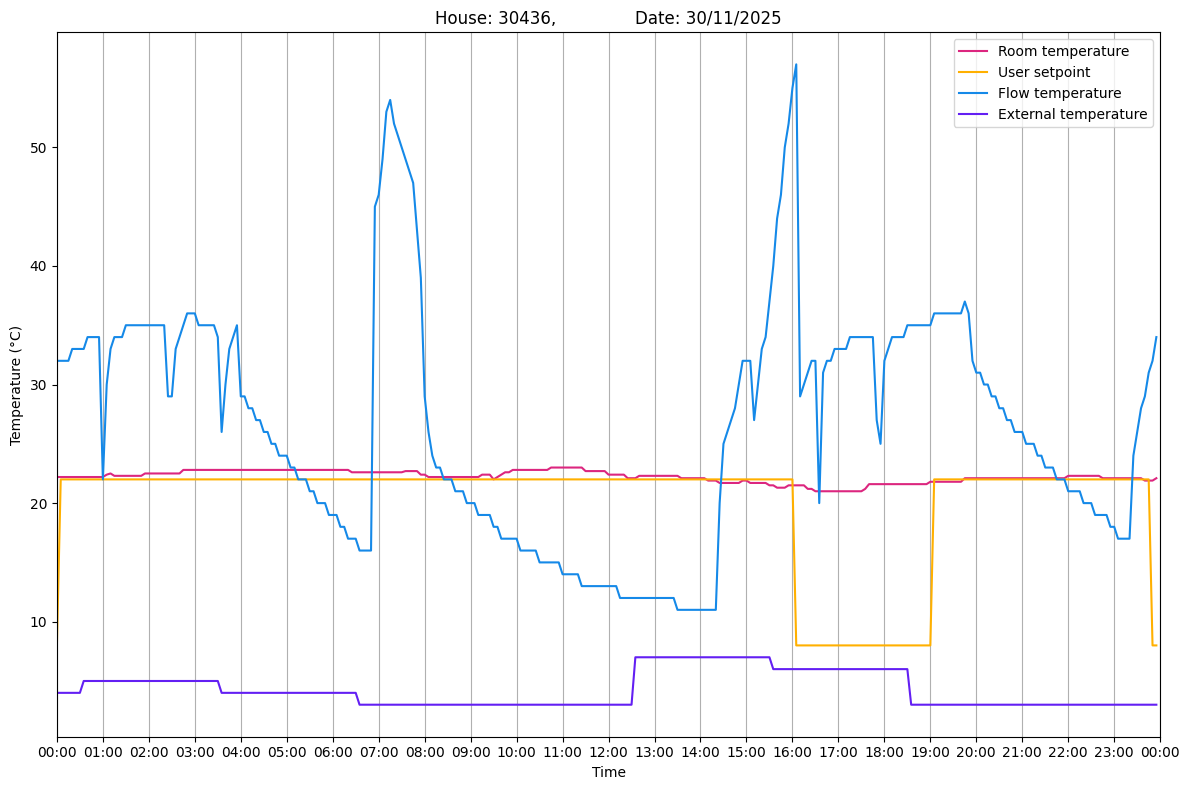

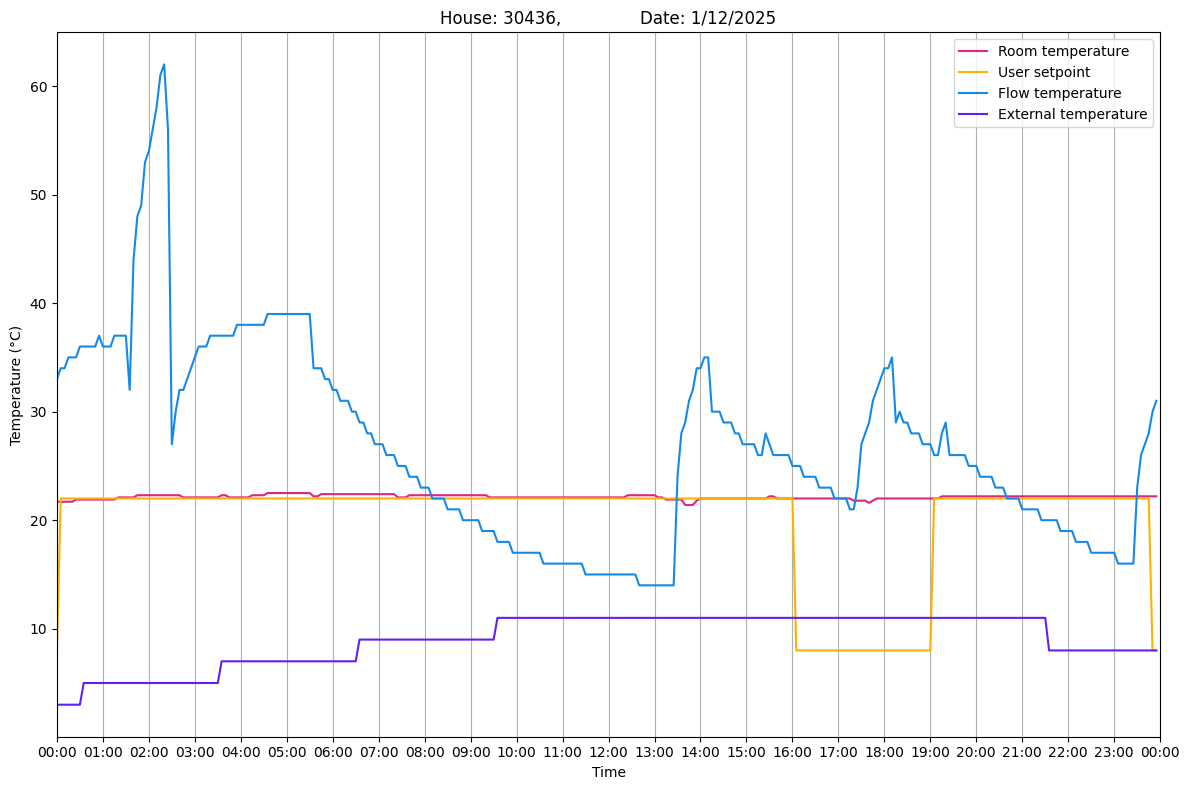

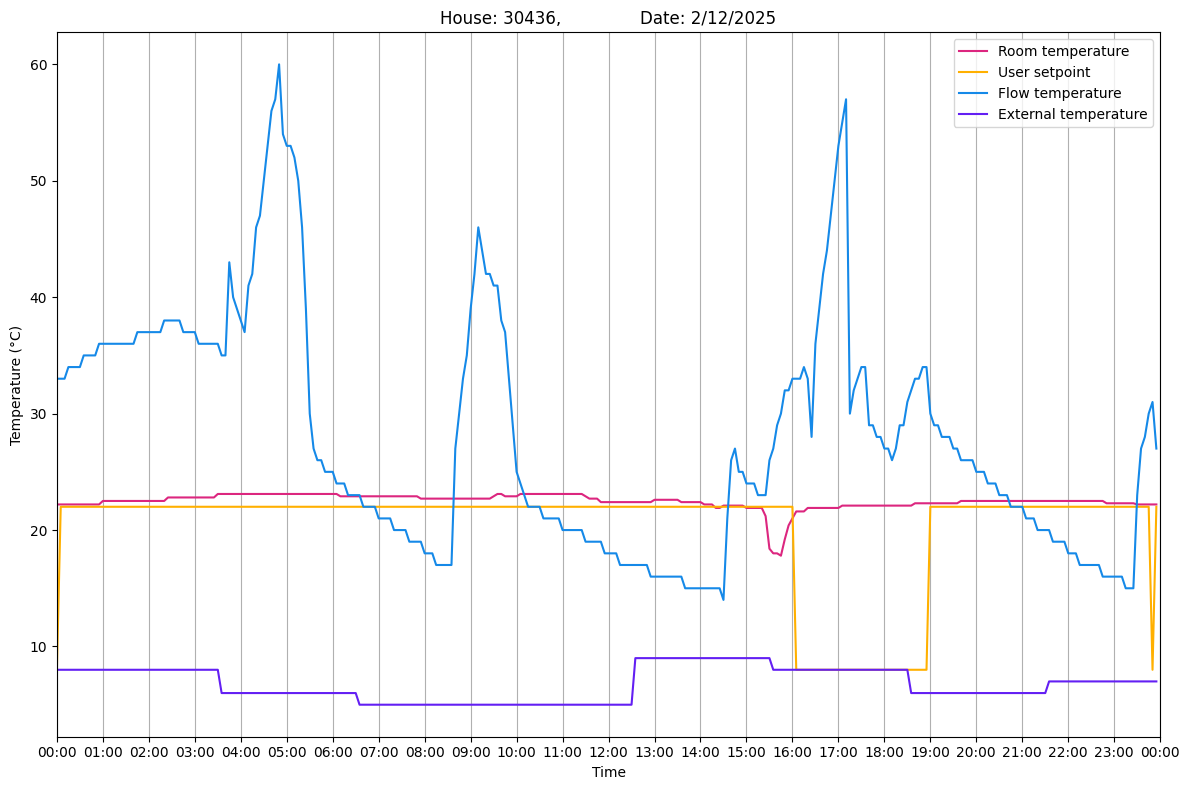

In [76]:
week_to_plot = 8  # Should be an int <= num_weeks corresponding to which week from the above graphs to zoom in on
for i in range(7):
    # Slice by day
    start_index = datapoints_in_week*week_to_plot + i*datapoints_in_day
    end_index = datapoints_in_week*week_to_plot + i*datapoints_in_day + datapoints_in_day

    dates = house_df["Datetime"][start_index:end_index]
    room_temp = house_df["Room temperature (Zone 1) (°C)"][start_index:end_index]
    user_setpoint = house_df["Setpoint temperature (Zone 1) (°C)"][start_index:end_index]
    flow_temp = house_df["Flow temperature (°C)"][start_index:end_index]
    # flow_setpoint = house_df["Flow temperature setpoint (°C)"][start_index:end_index]
    ext_temp = house_df["External temperature (°C)"][start_index:end_index]

    # Plot temperature variation across training dataset
    fig = plt.figure(figsize=(12,8), layout="tight")
    plt.plot(dates, room_temp, label="Room temperature", c=colours[0])
    plt.plot(dates, user_setpoint, label="User setpoint", c=colours[1])
    plt.plot(dates, flow_temp, label="Flow temperature", c=colours[2])
    # plt.plot(dates, flow_setpoint, label="Flow setpoint")
    plt.plot(dates, ext_temp, label="External temperature", c=colours[3])
    ax = plt.gca()
    ax.xaxis.set_major_locator(HourLocator(interval=1))
    ax.xaxis.set_major_formatter(DateFormatter('%H:%M'))
    plt.xlim(house_df["Datetime"][start_index],house_df["Datetime"][end_index])
    plt.grid(visible=True, axis="x")
    plt.xlabel("Time")
    plt.ylabel("Temperature (°C)")
    plt.title(f"House: {house_id}, \
              Date: {dates[start_index].day}/{dates[start_index].month}/{dates[start_index].year}")
    plt.legend()
    plt.show()